# Vortrag 4: Das Simpson-Paradoxon an der UC Berkeley (Zulassungen 1973)

**Kurs:** Statistik (w.BA.XX.2Stat-WIN.XX), Wirtschaftsinformatik, Kleinklasse HS 2026
**Gruppe:** Leorat Krasniqi, Teoman-Doganay Lam, Filip Lazic
**Datengrundlage:** Tabelle 4 der Aufgabenstellung (ZHAW School of Management and Law [ZHAW SML], 2026) bzw. Originaldaten von Bickel et al. (1975)

Aufbau des Notebooks:

1. Vorüberlegungen zur programmtechnischen Umsetzung
2. Daten aus Tabelle 4 erfassen, bereinigen und prüfen
3. Hilfsfunktionen (Anwendung der Konzepte aus McKinney, 2018, Abschnitt 3.2)
4. Aufgabe (b): Darstellung der Verhältnisse, die auf eine Ungerechtigkeit schliessen lassen
5. Aufgabe (c): Vergleich der Verteilungen und stochastische Unabhängigkeit
6. Fazit
7. Literaturverzeichnis (APA 7)

## 1. Vorüberlegungen zur programmtechnischen Umsetzung

**Was liegt vor?** Tabelle 4 enthält je Fachbereich (A bis F) nur *relative* Werte:

* die Zulassungsquote je Geschlecht $G$ und Fachbereich $F_i$, also die bedingte Wahrscheinlichkeit $P(Z \mid F_i, G)$, und
* den Anteil der Bewerbungen je Fachbereich innerhalb eines Geschlechts, also $P(F_i \mid G)$.

**Was folgt daraus für den Code?**

* Die Tabelle wird wortgetreu als Text erfasst (z. B. `"82.4%"`) und mit eigenen Funktionen in Zahlen
  umgewandelt. Damit bleibt die Datenerfassung nachvollziehbar, und Tippfehler fallen durch eine
  Fehlerbehandlung auf (McKinney, 2018, S. 74–75, 79–80).
* Die Zeile *Total* lässt sich aus den Fachbereichswerten nachrechnen (Satz der totalen
  Wahrscheinlichkeit, vgl. «alle Wege nach B» im Baumdiagramm; Schnauss, o. J.-b, Folie 37).
  Das dient als Plausibilitätskontrolle der erfassten Daten.
* Für $P(W)$ und $P(Z \cap W)$ fehlt in Tabelle 4 das Verhältnis Frauen zu Männern. Wir übernehmen
  deshalb die Anzahlen des Originaldatensatzes (Bickel et al., 1975; R Core Team, o. J.) und prüfen per
  Code, dass sie alle Prozentwerte von Tabelle 4 reproduzieren.
* Wiederkehrende Schritte (Kreuztabelle bilden, Unabhängigkeit prüfen, Diagramm zeichnen) werden als
  **Funktionen** umgesetzt, weil sie einmal für alle Fachbereiche zusammen und sechsmal je Fachbereich
  gebraucht werden. Das entspricht der Faustregel von McKinney (2018, S. 71): Wer denselben Code mehr als
  einmal braucht, schreibt besser eine Funktion.
* Darstellung wie im Kurs: Säulendiagramme für kategoriale Daten, gruppierte Säulendiagramme für
  Kreuztabellen und ein Streudiagramm für zwei metrische Grössen (Schnauss, o. J.-a, Folien 16, 42, 45).

**Verwendete Libraries und Begründung**

| Library | Zweck | Begründung |
|---|---|---|
| `pandas` | Tabellen (DataFrame), `pivot_table`, `groupby` | Standard für tabellarische Daten in Python (McKinney, 2018); Kreuztabellen entstehen in einer Zeile |
| `numpy` | Rechnen auf ganzen Spalten, Korrelation | Grundlage von pandas; kein Schleifen-Code für einfache Rechnungen nötig |
| `matplotlib` | Alle Diagramme | Volle Kontrolle über Farben, Beschriftungen und PNG-Export für Ausarbeitung und Folien |
| `re`, `functools` | Bereinigung der Prozent-Strings, `partial` | Standardbibliothek, keine Installation nötig; direkt aus McKinney (2018, S. 74, 77) |

Der Kurs arbeitet mit Anaconda und Jupyter (ZHAW SML, 2019); pandas, NumPy und Matplotlib sind dort
bereits enthalten.

In [1]:
# --- Imports -------------------------------------------------------------
import re                              # reguläre Ausdrücke zum Bereinigen der Strings
from functools import partial          # Currying (McKinney, 2018, S. 76-77)

import numpy as np                     # numerische Berechnungen
import pandas as pd                    # Tabellen / DataFrames
import matplotlib.pyplot as plt        # Diagramme

# Einheitliches Aussehen: eine feste Farbe pro Geschlecht in ALLEN Diagrammen
FARBEN = {"Frauen": "#eb6834", "Männer": "#2a78d6"}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#dddddd",
    "font.size": 11,
})
ABB_ORDNER = "abbildungen/"   # hier werden die PNGs für Ausarbeitung und Folien gespeichert

## 2. Daten aus Tabelle 4 erfassen, bereinigen und prüfen

Die Werte werden exakt so übernommen, wie sie in Tabelle 4 stehen. Die Bereinigung folgt dem Muster
`clean_strings` aus McKinney (2018, S. 74–75): Eine **Liste von Funktionen** wird nacheinander auf
jeden Wert angewendet, denn Funktionen sind in Python Objekte.

In [2]:
# Tabelle 4 wortgetreu als Dictionary: Schlüssel = Spaltenname, Wert = Liste von Strings
tabelle4_roh = {
    "Fachbereich":   ["A", "B", "C", "D", "E", "F"],
    "Quote_Frauen":  ["82.4%", "68.0%", "34.1%", "34.9%", "23.9%", "7.0%"],
    "Quote_Männer":  ["62.1%", "63.0%", "36.9%", "33.1%", "27.7%", "5.9%"],
    "Anteil_Frauen": ["5.9%", "1.4%", "32.3%", "20.4%", "21.4%", "18.6%"],
    "Anteil_Männer": ["30.7%", "20.8%", "12.1%", "15.5%", "7.1%", "13.9%"],
}
TOTAL_QUOTE = {"Frauen": 0.304, "Männer": 0.445}   # Zeile "Total" aus Tabelle 4


def entferne_prozentzeichen(wert):
    # Entfernt Prozentzeichen und Leerzeichen, z. B. " 82.4% " -> "82.4"
    return re.sub(r"[%\s]", "", wert)


def in_anteil(wert):
    # Wandelt "82.4" in 0.824 um. Nur der erwartete ValueError wird abgefangen
    # (McKinney, 2018, S. 80): Ein Tippfehler in der Tabelle soll mit einer klaren
    # Meldung abbrechen, statt stillschweigend eine falsche Zahl zu liefern.
    try:
        return float(wert) / 100
    except ValueError:
        raise ValueError(f"Ungültiger Tabellenwert: {wert!r}")


# Funktionen sind Objekte: die Bereinigungsschritte stehen in einer Liste ...
bereinigungs_schritte = [str.strip, entferne_prozentzeichen, in_anteil]


def bereinige(werte, schritte):
    # ... und werden der Reihe nach auf jeden Wert angewendet.
    ergebnis = []
    for wert in werte:
        for funktion in schritte:
            wert = funktion(wert)
        ergebnis.append(wert)
    return ergebnis


# DataFrame aufbauen: Fachbereich bleibt Text, alle anderen Spalten werden bereinigt
tab4 = pd.DataFrame({
    spalte: werte if spalte == "Fachbereich" else bereinige(werte, bereinigungs_schritte)
    for spalte, werte in tabelle4_roh.items()
}).set_index("Fachbereich")
tab4

,Quote_Frauen,Quote_Männer,Anteil_Frauen,Anteil_Männer
Fachbereich,,,,
A,0.824,0.621,0.059,0.307
B,0.680,0.630,0.014,0.208
C,0.341,0.369,0.323,0.121
D,0.349,0.331,0.204,0.155
E,0.239,0.277,0.214,0.071
F,0.070,0.059,0.186,0.139


### Plausibilitätskontrolle mit dem Satz der totalen Wahrscheinlichkeit

Im Baumdiagramm ergibt sich die Wahrscheinlichkeit eines Ereignisses als Summe über «alle Wege»
dorthin (Schnauss, o. J.-b, Folie 37). Verallgemeinert auf sechs Fachbereiche:

$$P(Z \mid G) = \sum_{i=A}^{F} P(F_i \mid G)\cdot P(Z \mid F_i, G)$$

Die Gesamtquote eines Geschlechts ist also ein **gewichteter Mittelwert** der Fachbereichsquoten.
Gewichtet wird mit der Verteilung der Bewerbungen auf die Fachbereiche.

In [3]:
def gesamtquote(quoten, anteile):
    # Satz der totalen Wahrscheinlichkeit: Summe über (Anteil * Quote).
    # quoten und anteile sind pandas-Series mit dem Fachbereich als Index.
    return float((quoten * anteile).sum())


for g in ["Frauen", "Männer"]:
    berechnet = gesamtquote(tab4[f"Quote_{g}"], tab4[f"Anteil_{g}"])
    print(f"{g:7s}: berechnet {berechnet:.1%}   laut Tabelle {TOTAL_QUOTE[g]:.1%}")

Frauen : berechnet 30.4%   laut Tabelle 30.4%
Männer : berechnet 44.6%   laut Tabelle 44.5%


Die berechneten Gesamtquoten stimmen bis auf Rundungsdifferenzen (höchstens 0.1 Prozentpunkte, weil
Tabelle 4 auf eine Nachkommastelle gerundet ist) mit der Zeile *Total* überein.

### Absolute Häufigkeiten

Für $P(W)$ und $P(Z \cap W)$ braucht es Anzahlen. Aus den gerundeten Prozenten lassen sie sich nicht
exakt zurückrechnen (ein Versuch ergibt z. B. 26 statt 25 Bewerbungen von Frauen in Fachbereich B).
Wir übernehmen deshalb die Anzahlen des Originaldatensatzes, der in R als `UCBAdmissions` verfügbar ist
(R Core Team, o. J.; Bickel et al., 1975), und **prüfen, dass sie Tabelle 4 reproduzieren**.

In [4]:
# Originaldaten: (zugelassen, abgelehnt) je Geschlecht und Fachbereich
ORIGINAL = {
    "Frauen": {"A": (89, 19),   "B": (17, 8),    "C": (202, 391),
               "D": (131, 244), "E": (94, 299),  "F": (24, 317)},
    "Männer": {"A": (512, 313), "B": (353, 207), "C": (120, 205),
               "D": (138, 279), "E": (53, 138),  "F": (22, 351)},
}


def kennzahlen(zugelassen, abgelehnt, total_bewerbungen):
    # Gibt zwei Werte zurück, technisch ein Tupel (McKinney, 2018, S. 73):
    # die Zulassungsquote und den Anteil an allen Bewerbungen des Geschlechts.
    bewerbungen = zugelassen + abgelehnt
    return zugelassen / bewerbungen, bewerbungen / total_bewerbungen


# "Langes" Datenformat: eine Zeile pro Fachbereich x Geschlecht x Entscheid
zeilen = []
for g, fachbereiche in ORIGINAL.items():
    for fb_name, (zul, abg) in fachbereiche.items():        # Tupel direkt entpacken
        zeilen.append({"Fachbereich": fb_name, "Geschlecht": g,
                       "Entscheid": "zugelassen", "Anzahl": zul})
        zeilen.append({"Fachbereich": fb_name, "Geschlecht": g,
                       "Entscheid": "abgelehnt", "Anzahl": abg})
daten = pd.DataFrame(zeilen)

# Gegenprobe gegen Tabelle 4 (dort auf eine Nachkommastelle in Prozent gerundet)
abweichungen = 0
for g, fachbereiche in ORIGINAL.items():
    n_g = sum(zul + abg for zul, abg in fachbereiche.values())
    for fb_name, (zul, abg) in fachbereiche.items():
        quote, anteil = kennzahlen(zul, abg, n_g)
        # Toleranz: halbe Rundungseinheit von Tabelle 4 (0.05 Prozentpunkte)
        if abs(quote - tab4.loc[fb_name, f"Quote_{g}"]) > 0.0005 or \
           abs(anteil - tab4.loc[fb_name, f"Anteil_{g}"]) > 0.0005:
            abweichungen += 1
            print("Abweichung:", g, fb_name, quote, anteil)
    print(f"{g}: {n_g} Bewerbungen")
print("Abweichungen zu Tabelle 4:", abweichungen)

# Übersicht der Anzahlen (Zeilen = Fachbereich, Spalten = Geschlecht x Entscheid)
daten.pivot_table(index="Fachbereich", columns=["Geschlecht", "Entscheid"],
                  values="Anzahl", aggfunc="sum")

Frauen: 1835 Bewerbungen
Männer: 2691 Bewerbungen
Abweichungen zu Tabelle 4: 0


Geschlecht     Frauen               Männer           
Entscheid   abgelehnt zugelassen abgelehnt zugelassen
Fachbereich                                          
A                  19         89       313        512
B                   8         17       207        353
C                 391        202       205        120
D                 244        131       279        138
E                 299         94       138         53
F                 317         24       351         22

## 3. Hilfsfunktionen für die Analyse

Die folgenden Funktionen werden für alle Fachbereiche zusammen **und** für jeden einzelnen Fachbereich
verwendet. Sie zeigen die Konzepte aus McKinney (2018, S. 71–81): Keyword-Argument mit Standardwert,
Rückgabe eines Dictionarys, Lambda-Funktionen, Currying mit `partial` und einen Generator mit `yield`.

In [5]:
def kreuztabelle(daten, fachbereich=None):
    # Kreuztabelle (Vierfeldertafel) Geschlecht x Entscheid.
    # fachbereich ist ein Keyword-Argument mit Standardwert None (McKinney, 2018, S. 72):
    #   None -> alle Fachbereiche zusammen, sonst nur der gewählte Fachbereich.
    if fachbereich is not None:
        daten = daten[daten["Fachbereich"] == fachbereich]
    return daten.pivot_table(index="Geschlecht", columns="Entscheid",
                             values="Anzahl", aggfunc="sum")[["zugelassen", "abgelehnt"]]


def bedingte_quote(tafel, geschlecht):
    # P(Z | G) = Anzahl Zugelassene des Geschlechts / Anzahl Bewerbungen des Geschlechts
    return tafel.loc[geschlecht, "zugelassen"] / tafel.loc[geschlecht].sum()


# Currying (McKinney, 2018, S. 76-77): aus der allgemeinen Funktion zwei spezielle ableiten
quote_frauen = partial(bedingte_quote, geschlecht="Frauen")
quote_maenner = partial(bedingte_quote, geschlecht="Männer")


def pruefe_unabhaengigkeit(tafel):
    # Vergleicht P(Z ∩ W) mit P(Z) · P(W) (Definition: Schnauss, o. J.-b, Folie 34).
    # Rückgabe als Dictionary (McKinney, 2018, S. 74): Die Kennzahlen sind so über
    # ihren Namen ansprechbar, und mehrere Dictionaries ergeben direkt ein DataFrame.
    n = tafel.values.sum()
    p_w = tafel.loc["Frauen"].sum() / n                  # P(W)
    p_z = tafel["zugelassen"].sum() / n                  # P(Z)
    p_z_und_w = tafel.loc["Frauen", "zugelassen"] / n    # P(Z ∩ W)
    differenz = quote_frauen(tafel) - quote_maenner(tafel)
    return {
        "n": int(n),
        "P(Z)": p_z,
        "P(W)": p_w,
        "P(Z|W)": quote_frauen(tafel),
        "P(Z|M)": quote_maenner(tafel),
        "Differenz (PP)": differenz * 100,
        "P(Z∩W)": p_z_und_w,
        "P(Z)·P(W)": p_z * p_w,
        "Richtung": "zugunsten Frauen" if differenz > 0 else "zugunsten Männer",
    }


def ergebnisse_je_fachbereich(daten, fachbereiche):
    # Generator (McKinney, 2018, S. 77-78): liefert die Ergebnisse Fachbereich für
    # Fachbereich erst dann, wenn sie angefordert werden (Lazy Evaluation).
    for fb in fachbereiche:
        yield fb, pruefe_unabhaengigkeit(kreuztabelle(daten, fachbereich=fb))


# Lambda-Funktionen für die Formatierung der Ausgaben (McKinney, 2018, S. 75-76)
prozent = lambda x: f"{x:.1%}"
vier_stellen = lambda x: f"{x:.4f}"

## 4. Aufgabe (b): Darstellung der Verhältnisse

Ein Betrachter soll *schnell* erkennen, weshalb das Zulassungsverfahren ungerecht wirkt. Dafür genügt ein
einziger Vergleich: die **Gesamtzulassungsquote von Frauen und Männern**. Ein Säulendiagramm ist dafür
geeignet, weil die Höhe der Säulen proportional zur relativen Häufigkeit ist (Schnauss, o. J.-a, Folie 16).
Die Nullachse bleibt sichtbar, die Werte stehen direkt über den Säulen und die Differenz ist eingezeichnet.

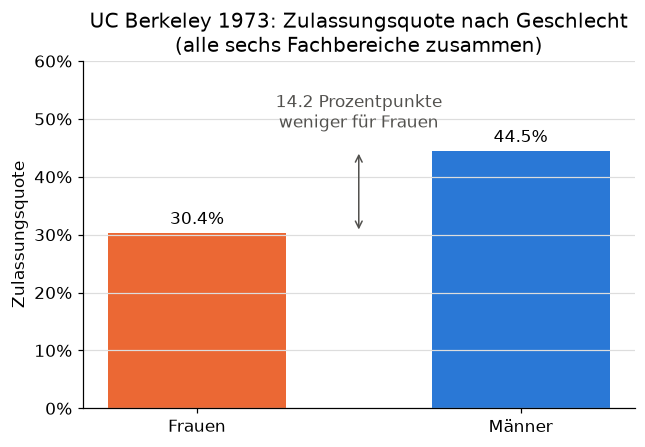

In [6]:
def saeulen_beschriften(ax, saeulen, format_funktion=prozent):
    # Schreibt den Wert über jede Säule. Die Formatierung wird als Funktion
    # übergeben (Funktionen als Argumente anderer Funktionen).
    for s in saeulen:
        ax.annotate(format_funktion(s.get_height()),
                    (s.get_x() + s.get_width() / 2, s.get_height()),
                    ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")


gesamt = pruefe_unabhaengigkeit(kreuztabelle(daten))
quoten_gesamt = {"Frauen": gesamt["P(Z|W)"], "Männer": gesamt["P(Z|M)"]}
differenz = quoten_gesamt["Männer"] - quoten_gesamt["Frauen"]

fig, ax = plt.subplots(figsize=(6, 4.2))
saeulen = ax.bar(list(quoten_gesamt), list(quoten_gesamt.values()), width=0.55,
                 color=[FARBEN[g] for g in quoten_gesamt])
saeulen_beschriften(ax, saeulen)
# Differenz als Doppelpfeil zwischen den beiden Säulenhöhen
ax.annotate("", xy=(0.5, quoten_gesamt["Frauen"]), xytext=(0.5, quoten_gesamt["Männer"]),
            arrowprops=dict(arrowstyle="<->", color="#52514e"))
ax.text(0.5, quoten_gesamt["Männer"] + 0.04,
        f"{differenz * 100:.1f} Prozentpunkte\nweniger für Frauen", ha="center", color="#52514e")
ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set_ylabel("Zulassungsquote")
ax.set_title("UC Berkeley 1973: Zulassungsquote nach Geschlecht\n(alle sechs Fachbereiche zusammen)")
fig.tight_layout()
fig.savefig(ABB_ORDNER + "abb1_gesamtquote.png", dpi=200)
plt.show()

In [7]:
# Dieselbe Aussage in Zahlen
n_frauen = int(kreuztabelle(daten).loc["Frauen"].sum())
print(f"Zulassungsquote Männer: {quoten_gesamt['Männer']:.2%}, Frauen: {quoten_gesamt['Frauen']:.2%}")
print(f"Differenz: {differenz * 100:.1f} Prozentpunkte")
print(f"Verhältnis der Zulassungsquoten Männer/Frauen: {quoten_gesamt['Männer'] / quoten_gesamt['Frauen']:.2f}")
print("Zugelassene Frauen tatsächlich:    ", round(n_frauen * quoten_gesamt["Frauen"]))
print("Zugelassene Frauen bei Männerquote:", round(n_frauen * quoten_gesamt["Männer"]))

Zulassungsquote Männer: 44.52%, Frauen: 30.35%
Differenz: 14.2 Prozentpunkte
Verhältnis der Zulassungsquoten Männer/Frauen: 1.47
Zugelassene Frauen tatsächlich:     557
Zugelassene Frauen bei Männerquote: 817


**Zwischenfazit (b):** Männer wurden zu 44.5 % zugelassen, Frauen nur zu 30.4 %. Das sind 14.2
Prozentpunkte weniger (exakt 44.52 % − 30.35 %), die Quote der Männer ist rund 1.47-mal so hoch. Auf den
ersten Blick spricht das für eine Benachteiligung der Frauen. Ob dieser Schluss trägt, klärt Aufgabe (c).

## 5. Aufgabe (c): Vergleich der Verteilungen

### 5.1 Zulassungsquoten je Fachbereich

Gruppierte Säulendiagramme eignen sich, um Kreuztabellen darzustellen (Schnauss, o. J.-a, Folie 42).

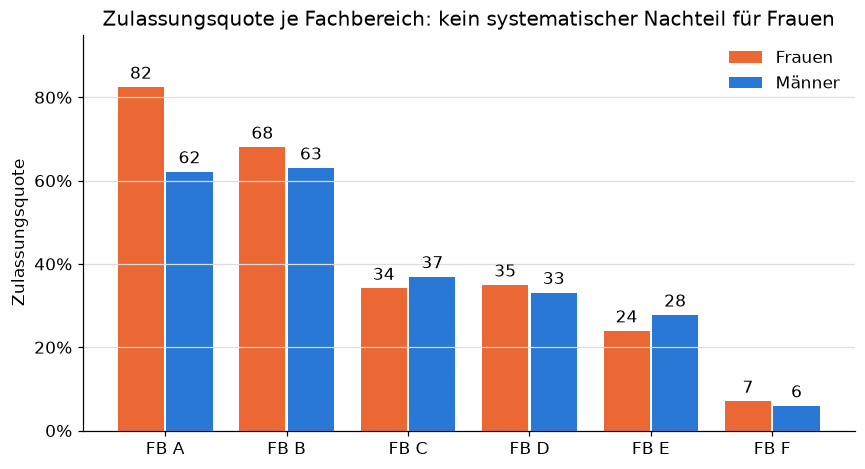

In [8]:
def gruppiertes_saeulendiagramm(tab, spalten_praefix, titel, ylabel, dateiname, ylim=None):
    # Zeichnet je Fachbereich eine Säule für Frauen und eine für Männer.
    # Wird für Quoten UND Anteile verwendet -> eine Funktion statt doppeltem Code.
    x = np.arange(len(tab.index))
    breite = 0.38
    fig, ax = plt.subplots(figsize=(8, 4.4))
    for i, g in enumerate(["Frauen", "Männer"]):
        saeulen = ax.bar(x + (i - 0.5) * (breite + 0.02), tab[f"{spalten_praefix}_{g}"],
                         width=breite, color=FARBEN[g], label=g)
        saeulen_beschriften(ax, saeulen, format_funktion=lambda v: f"{v * 100:.0f}")
    ax.set_xticks(x, [f"FB {fb}" for fb in tab.index])
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(titel)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ABB_ORDNER + dateiname, dpi=200)
    plt.show()


gruppiertes_saeulendiagramm(tab4, "Quote",
    "Zulassungsquote je Fachbereich: kein systematischer Nachteil für Frauen",
    "Zulassungsquote", "abb2_quote_fachbereich.png", ylim=(0, 0.95))

In [9]:
# Differenz Frauen minus Männer je Fachbereich in Prozentpunkten (aus den Anzahlen, ungerundet)
diff = pd.Series({fb: (quote_frauen(kreuztabelle(daten, fb)) - quote_maenner(kreuztabelle(daten, fb))) * 100
                  for fb in tab4.index}).round(1)
print(diff.to_string())
print("Fachbereiche, in denen Frauen eine höhere Quote haben:", list(diff[diff > 0].index))

A    20.3
B     5.0
C    -2.9
D     1.8
E    -3.8
F     1.1
Fachbereiche, in denen Frauen eine höhere Quote haben: ['A', 'B', 'D', 'F']


### 5.2 Verteilung der Bewerbungen auf die Fachbereiche

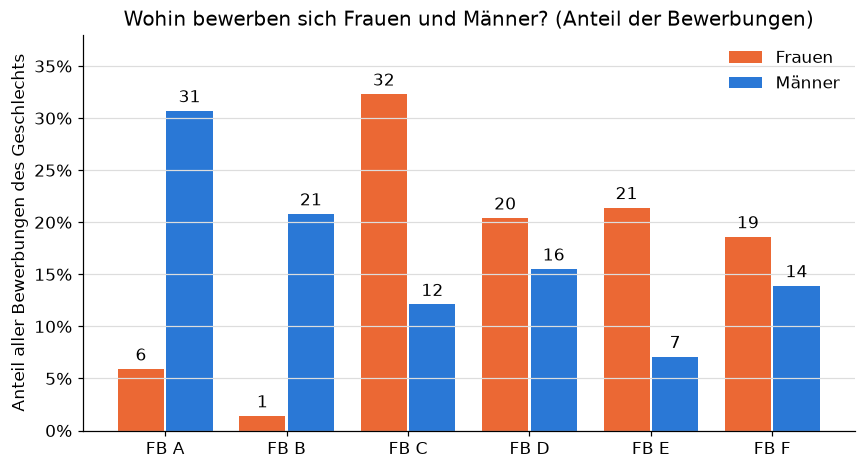

Frauen: 7.2% der Bewerbungen in A oder B
Männer: 51.5% der Bewerbungen in A oder B


In [10]:
gruppiertes_saeulendiagramm(tab4, "Anteil",
    "Wohin bewerben sich Frauen und Männer? (Anteil der Bewerbungen)",
    "Anteil aller Bewerbungen des Geschlechts", "abb3_anteil_fachbereich.png", ylim=(0, 0.38))

# Anteil der Bewerbungen in den Fachbereichen A und B (hohe Zulassungsquoten)
for g in ["Frauen", "Männer"]:
    bew = daten[daten.Geschlecht == g].groupby("Fachbereich")["Anzahl"].sum()
    print(f"{g}: {bew[['A', 'B']].sum() / bew.sum():.1%} der Bewerbungen in A oder B")

### 5.3 Zusammenhang: Frauen bewarben sich häufiger in selektiven Fachbereichen

Frauenanteil und Zulassungsquote sind zwei metrische Grössen je Fachbereich, deshalb eignet sich ein
Streudiagramm (Schnauss, o. J.-a, Folie 45). Die Punktfläche ist proportional zur Anzahl Bewerbungen.

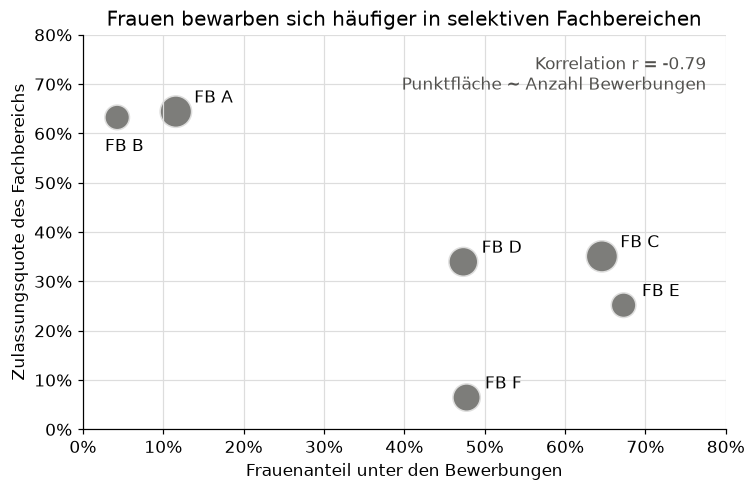

Entscheid,Bewerbungen,Quote_gesamt,Frauenanteil
Fachbereich,,,
A,933,64.4%,11.6%
B,585,63.2%,4.3%
C,918,35.1%,64.6%
D,792,34.0%,47.3%
E,584,25.2%,67.3%
F,714,6.4%,47.8%


In [11]:
# Kennzahlen je Fachbereich aus den Anzahlen
fb = daten.pivot_table(index="Fachbereich", columns="Entscheid", values="Anzahl", aggfunc="sum")
fb["Bewerbungen"] = fb["zugelassen"] + fb["abgelehnt"]
fb["Quote_gesamt"] = fb["zugelassen"] / fb["Bewerbungen"]
fb["Frauenanteil"] = (daten[daten.Geschlecht == "Frauen"]
                      .groupby("Fachbereich")["Anzahl"].sum() / fb["Bewerbungen"])

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(fb["Frauenanteil"], fb["Quote_gesamt"], s=fb["Bewerbungen"] / 2,
           color="#52514e", alpha=0.75, edgecolor="white", linewidth=2)
for name, zeile in fb.iterrows():
    # FB B liegt dicht neben FB A -> Beschriftung dort nach unten verschieben
    versatz = (-8, -22) if name == "B" else (12, 6)
    ax.annotate(f"FB {name}", (zeile["Frauenanteil"], zeile["Quote_gesamt"]),
                xytext=versatz, textcoords="offset points")
r = np.corrcoef(fb["Frauenanteil"], fb["Quote_gesamt"])[0, 1]
ax.set_xlim(0, 0.8); ax.set_ylim(0, 0.8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Frauenanteil unter den Bewerbungen")
ax.set_ylabel("Zulassungsquote des Fachbereichs")
ax.set_title("Frauen bewarben sich häufiger in selektiven Fachbereichen")
ax.text(0.97, 0.95, f"Korrelation r = {r:.2f}\nPunktfläche ~ Anzahl Bewerbungen",
        transform=ax.transAxes, ha="right", va="top", color="#52514e")
ax.grid(True, axis="both")
fig.tight_layout()
fig.savefig(ABB_ORDNER + "abb4_selektivitaet.png", dpi=200)
plt.show()
fb[["Bewerbungen", "Quote_gesamt", "Frauenanteil"]].style.format(
    {"Quote_gesamt": prozent, "Frauenanteil": prozent})

### 5.4 Standardisierung: Was wäre bei gleicher Fachbereichswahl?

In die Formel der totalen Wahrscheinlichkeit setzen wir für **beide** Geschlechter dieselben Gewichte
ein, nämlich die Verteilung *aller* Bewerbungen auf die Fachbereiche. Dann bleibt nur noch der
Unterschied der Quoten innerhalb der Fachbereiche übrig.

       tatsächlich (eigene Fachbereichswahl)  \
Frauen                                 30.4%   
Männer                                 44.5%   

       standardisiert (gleiche Fachbereichswahl)  
Frauen                                     43.0%  
Männer                                     38.7%  


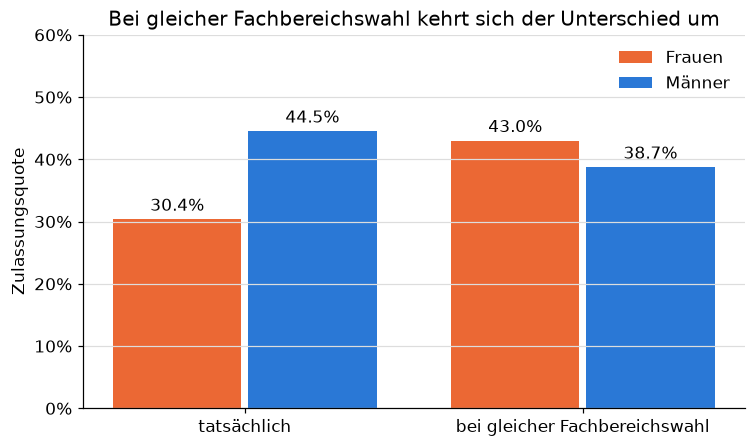

In [12]:
gewichte_alle = fb["Bewerbungen"] / fb["Bewerbungen"].sum()   # gemeinsame Fachbereichsverteilung

# Exakte Quoten und Anteile je Geschlecht aus den Anzahlen (statt der gerundeten Tabelle 4)
bew_g = daten.pivot_table(index="Fachbereich", columns="Geschlecht", values="Anzahl", aggfunc="sum")
zul_g = daten[daten.Entscheid == "zugelassen"].pivot_table(
    index="Fachbereich", columns="Geschlecht", values="Anzahl", aggfunc="sum")
quote_g = zul_g / bew_g                 # P(Z | Fachbereich, Geschlecht)
anteil_g = bew_g / bew_g.sum()          # P(Fachbereich | Geschlecht)

# Dieselbe Funktion gesamtquote, nur mit unterschiedlichen Gewichten
vergleich = pd.DataFrame({
    "tatsächlich (eigene Fachbereichswahl)": {
        g: gesamtquote(quote_g[g], anteil_g[g]) for g in ["Frauen", "Männer"]},
    "standardisiert (gleiche Fachbereichswahl)": {
        g: gesamtquote(quote_g[g], gewichte_alle) for g in ["Frauen", "Männer"]},
})
print(vergleich.map(prozent))

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(2)
for i, g in enumerate(["Frauen", "Männer"]):
    saeulen = ax.bar(x + (i - 0.5) * 0.4, vergleich.loc[g], width=0.38, color=FARBEN[g], label=g)
    saeulen_beschriften(ax, saeulen)
ax.set_xticks(x, ["tatsächlich", "bei gleicher Fachbereichswahl"])
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set_ylim(0, 0.6)
ax.set_ylabel("Zulassungsquote")
ax.set_title("Bei gleicher Fachbereichswahl kehrt sich der Unterschied um")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ABB_ORDNER + "abb5_standardisiert.png", dpi=200)
plt.show()

### 5.5 Stochastische Unabhängigkeit

Zwei Ereignisse $A$ und $B$ sind stochastisch unabhängig, falls $P(A \mid B) = P(A)$ bzw. gleichwertig
$P(A \cap B) = P(A)\cdot P(B)$ (Schnauss, o. J.-b, Folie 34). Hier ist $Z$ = «zugelassen» und
$W$ = «Bewerbung einer Frau».

Weil $P(Z)$ nach dem Satz der totalen Wahrscheinlichkeit ein gewichteter Mittelwert aus $P(Z \mid W)$
und $P(Z \mid M)$ ist, sind $Z$ und $W$ genau dann unabhängig, wenn **Frauen und Männer dieselbe
Zulassungsquote** haben. Wir prüfen das zuerst für alle Fachbereiche zusammen und danach innerhalb jedes
Fachbereichs (Unabhängigkeit *gegeben* den Fachbereich).

In [13]:
print("Kreuztabelle, alle Fachbereiche:")
print(kreuztabelle(daten), "\n")
print(f"P(Z)      = {gesamt['P(Z)']:.4f}    P(W) = {gesamt['P(W)']:.4f}")
print(f"P(Z|W)    = {gesamt['P(Z|W)']:.4f}    P(Z|M) = {gesamt['P(Z|M)']:.4f}")
print(f"P(Z∩W)    = {gesamt['P(Z∩W)']:.4f}")
print(f"P(Z)·P(W) = {gesamt['P(Z)·P(W)']:.4f}")
print(f"-> P(Z∩W) liegt {abs(gesamt['P(Z∩W)'] / gesamt['P(Z)·P(W)'] - 1):.0%} unter dem Wert bei Unabhängigkeit")

Kreuztabelle, alle Fachbereiche:
Entscheid   zugelassen  abgelehnt
Geschlecht                       
Frauen             557       1278
Männer            1198       1493 

P(Z)      = 0.3878    P(W) = 0.4054
P(Z|W)    = 0.3035    P(Z|M) = 0.4452
P(Z∩W)    = 0.1231
P(Z)·P(W) = 0.1572
-> P(Z∩W) liegt 22% unter dem Wert bei Unabhängigkeit


In [14]:
# Dieselbe Prüfung je Fachbereich: der Generator liefert (Fachbereich, Ergebnis)-Paare
je_fb = pd.DataFrame(dict(ergebnisse_je_fachbereich(daten, tab4.index))).T
je_fb[["n", "P(Z|W)", "P(Z|M)", "Differenz (PP)", "P(Z∩W)", "P(Z)·P(W)", "Richtung"]].style.format({
    "P(Z|W)": prozent, "P(Z|M)": prozent, "Differenz (PP)": "{:+.1f}",
    "P(Z∩W)": vier_stellen, "P(Z)·P(W)": vier_stellen})

,n,P(Z|W),P(Z|M),Differenz (PP),P(Z∩W),P(Z)·P(W),Richtung
A,933,82.4%,62.1%,+20.3,0.0954,0.0746,zugunsten Frauen
B,585,68.0%,63.0%,+5.0,0.0291,0.0270,zugunsten Frauen
C,918,34.1%,36.9%,-2.9,0.2200,0.2266,zugunsten Männer
D,792,34.9%,33.1%,+1.8,0.1654,0.1608,zugunsten Frauen
E,584,23.9%,27.7%,-3.8,0.1610,0.1694,zugunsten Männer
F,714,7.0%,5.9%,+1.1,0.0336,0.0308,zugunsten Frauen


In [15]:
# Wie viele Frauen haben sich je Fachbereich beworben? (wichtig für die Interpretation)
bewerbungen_frauen = daten[daten.Geschlecht == "Frauen"].groupby("Fachbereich")["Anzahl"].sum()
print(bewerbungen_frauen.to_string())

Fachbereich
A    108
B     25
C    593
D    375
E    393
F    341


**Interpretation:**

* **Alle Fachbereiche zusammen:** $P(Z \cap W) = 0.1231$ liegt rund 22 % unter
  $P(Z)\cdot P(W) = 0.1572$, und $P(Z \mid W) = 30.4\,\% \neq P(Z) = 38.8\,\%$. Zulassung und Geschlecht
  sind **stochastisch abhängig**.
* **Innerhalb der Fachbereiche:** In B bis F liegen $P(Z \cap W)$ und $P(Z)\cdot P(W)$ nahe beieinander.
  Die Differenzen der Quoten betragen höchstens 5 Prozentpunkte und wechseln die Richtung (B, D, F
  zugunsten der Frauen, C und E zugunsten der Männer). Ein systematisches Muster ist nicht erkennbar,
  wir sprechen von **annähernder Unabhängigkeit gegeben den Fachbereich**. Die +5.0 Prozentpunkte in B
  beruhen zudem auf nur 25 Bewerbungen von Frauen.
* **Fachbereich A** ist die Ausnahme: Frauen wurden mit 82.4 % deutlich häufiger zugelassen als
  Männer mit 62.1 % (+20.3 Prozentpunkte). Die Abhängigkeit geht hier also *zugunsten* der Frauen.
* Ob kleine Abweichungen wie in B bis F zufällig sind, liesse sich mit einem Hypothesentest prüfen.
  Hypothesentests werden erst später im Semester behandelt (ZHAW SML, 2023), deshalb bleibt die
  Beurteilung hier beschreibend.

## 6. Fazit

* **Aggregiert** (Aufgabe b): Frauen 30.4 % gegenüber Männern 44.5 %. Zulassung und Geschlecht sind
  stochastisch abhängig.
* **Je Fachbereich** (Aufgabe c): In 4 von 6 Fachbereichen haben Frauen die höhere Quote. Gegeben den
  Fachbereich sind Zulassung und Geschlecht annähernd unabhängig, einzig in A besteht ein deutlicher
  Unterschied, und zwar zugunsten der Frauen.
* **Ursache:** Frauen bewarben sich überwiegend in Fachbereichen mit tiefen Zulassungsquoten (C bis F),
  von den Männern gut die Hälfte in A und B mit hohen Quoten. Weil die Gesamtquote ein gewichteter Mittelwert ist,
  erzeugen die unterschiedlichen Gewichte den Unterschied. Bei gleicher Fachbereichswahl läge die Quote
  der Frauen sogar höher (43.0 % gegenüber 38.7 %). Ein solcher Umkehreffekt beim Zusammenfassen von
  Gruppen heisst **Simpson-Paradoxon** (Simpson, 1951); die Berkeley-Daten werden häufig zur
  Veranschaulichung verwendet (Bickel et al., 1975; R Core Team, o. J.).
* Die *scheinbare* Ungerechtigkeit ist deshalb kein Beleg für eine Benachteiligung durch die
  Fachbereiche. Offen bleibt, *warum* sich Frauen häufiger in stark umkämpften Fachbereichen bewarben.
  Das lässt sich mit diesen Daten nicht beantworten.

## 7. Literaturverzeichnis (APA 7)

Bickel, P. J., Hammel, E. A., & O'Connell, J. W. (1975). Sex bias in graduate admissions: Data from
Berkeley. *Science, 187*(4175), 398–404. https://doi.org/10.1126/science.187.4175.398

McKinney, W. (2018). *Datenanalyse mit Python* (2., korrigierte Aufl.). O'Reilly.

R Core Team. (o. J.). *UCBAdmissions: Student admissions at UC Berkeley* [Datensatz]. R-Paket datasets.
https://github.com/wch/r-source/blob/trunk/src/library/datasets/data/UCBAdmissions.R

Schnauss, M. (o. J.-a). *Statistik (w.BA.XX.2Stat-WIN.XX), Teil 1: Tabellen und Diagramme*
[Vorlesungsfolien]. ZHAW School of Management and Law.

Schnauss, M. (o. J.-b). *Statistik (w.BA.XX.2Stat-WIN.XX), Teil 3: Wahrscheinlichkeitsrechnung*
[Vorlesungsfolien]. ZHAW School of Management and Law.

Simpson, E. H. (1951). The interpretation of interaction in contingency tables. *Journal of the Royal
Statistical Society: Series B (Methodological), 13*(2), 238–241.
https://doi.org/10.1111/j.2517-6161.1951.tb00088.x

ZHAW School of Management and Law. (2019). *Aufgabe 1 (Installation)* [Aufgabenblatt].

ZHAW School of Management and Law. (2023). *Semesterplan Statistik (w.BA.XX.2Stat.XX), HS 2023/24*
[Semesterplan].

ZHAW School of Management and Law. (2026). *Aufgabe 4 (Vortrag-4: Python)* [Aufgabenblatt].